# Other Datasets EDA
All datasets' EDA (except sales, that has been done in a separate notebook).

# 1. Oil Dataset

## 1. 1. Load data and check general info

In [1]:
import pandas as pd
import numpy as np

df_oil = pd.read_csv('../data/oil.csv')

df_oil['date'] = pd.to_datetime(df_oil['date'])

# Filter test dates
df_oil = df_oil[df_oil['date'] <= '2017-08-15']

print(len(df_oil))
display(df_oil)

1206


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1201,2017-08-09,49.59
1202,2017-08-10,48.54
1203,2017-08-11,48.81
1204,2017-08-14,47.59


In [2]:
# General info
print(df_oil.info())
display(df_oil.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 1206 entries, 0 to 1205
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1206 non-null   datetime64[ns]
 1   dcoilwtico  1163 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 28.3 KB
None


,date,dcoilwtico
count,1206,1163.000000
mean,2015-04-24 02:24:28.656716288,67.925589
min,2013-01-01 00:00:00,26.190000
25%,2014-02-26 06:00:00,46.390000
50%,2015-04-23 12:00:00,53.330000
75%,2016-06-19 06:00:00,95.790000
max,2017-08-15 00:00:00,110.620000
std,NaN,25.677366


In [3]:
# Check for null values
null_count = df_oil.isnull().sum()
print(null_count)

date           0
dcoilwtico    43
dtype: int64


43 days without oil registers.

## 1. 2. Distribution plots

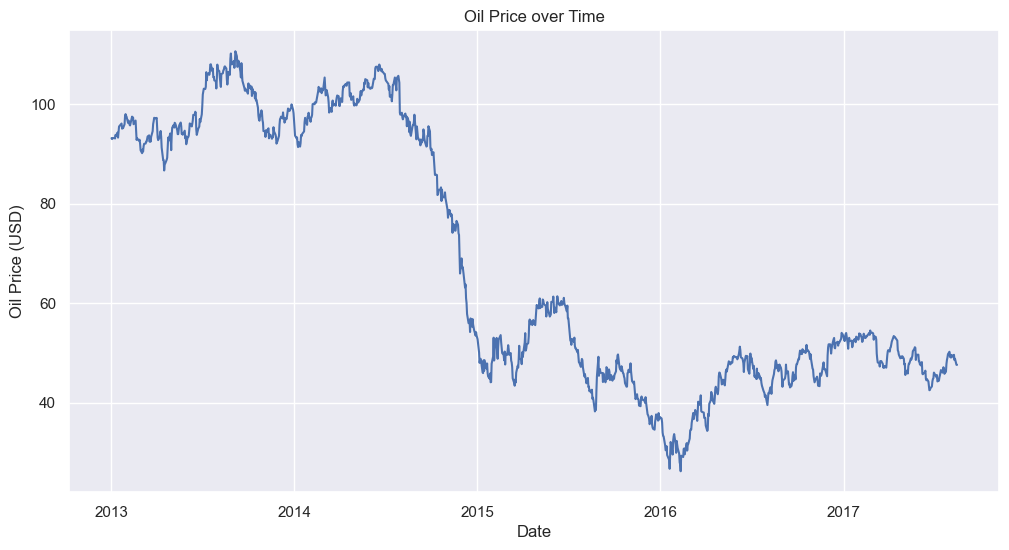

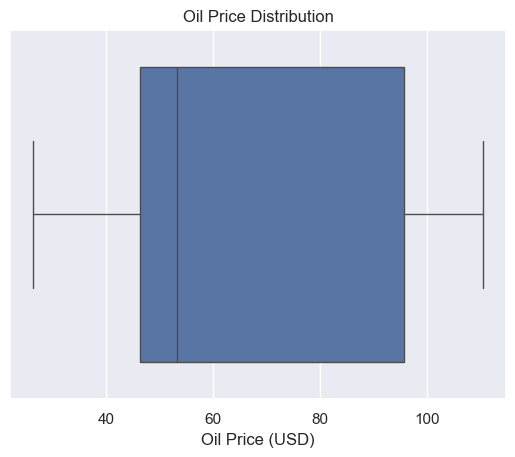

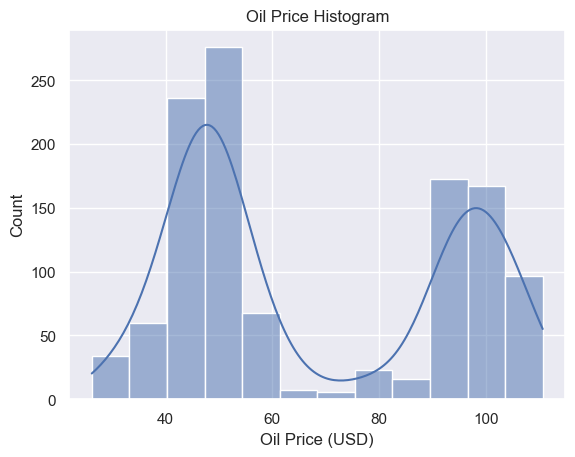

Skew: 0.3037406397173003
Kurtosis: -1.6229672851883834


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(x=df_oil['date'], y=df_oil['dcoilwtico'])

ax.set_title('Oil Price over Time')

ax.set_xlabel('Date')

# The competition does not
# specify the currency, so
# we assume it is in USD.
ax.set_ylabel('Oil Price (USD)')

plt.show()

ax = sns.boxplot(x=df_oil['dcoilwtico'])

ax.set_title('Oil Price Distribution')
ax.set_xlabel('Oil Price (USD)')

plt.show()

ax = sns.histplot(df_oil['dcoilwtico'], kde=True)

ax.set_title('Oil Price Histogram')
ax.set_xlabel('Oil Price (USD)')

plt.show()

print(f"Skew: {df_oil['dcoilwtico'].skew()}")
print(f"Kurtosis: {df_oil['dcoilwtico'].kurtosis()}")

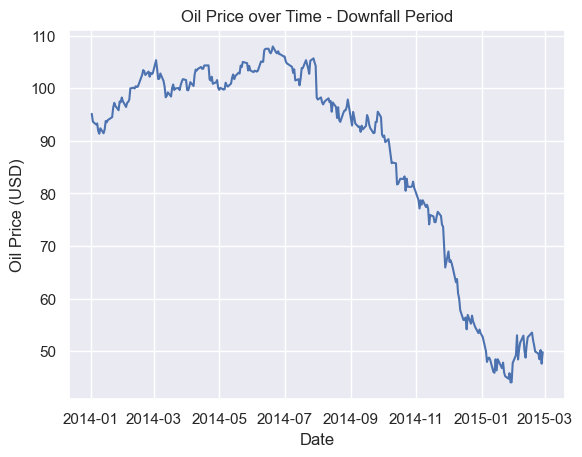

In [5]:
# Check downfall distribution to set downfall period
df_oil_downfall = df_oil[df_oil['date'].between('2014-01-01', '2015-02-28')]

ax = sns.lineplot(x=df_oil_downfall['date'], y=df_oil_downfall['dcoilwtico'])

ax.set_title('Oil Price over Time - Downfall Period')
ax.set_xlabel('Date')
ax.set_ylabel('Oil Price (USD)')

plt.show()

It may seem, looking at the boxplot, that the distribution is right-skewed. However, looking at the lineplot, we can see that there is a huge downfall on the oil price, making the data to have two clusters of values. This may lead to misinterpretations and to the Simpson Paradox when calculating the correlations.

To avoid this, let's make three separate distribution analysis: before mid July, 2014 (before the downfall started); from mid July, 2014 to mid January, 2015 (during the downfall); and after mid January, 2015 (after the downfall ended).

### 1. 2. 1. Distribution analysis - before downfall

400


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
395,2014-07-08,104.06
396,2014-07-09,102.93
397,2014-07-10,103.61
398,2014-07-11,101.48


<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        400 non-null    datetime64[ns]
 1   dcoilwtico  385 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.4 KB
None


,date,dcoilwtico
count,400,385.000000
mean,2013-10-06 21:36:00,99.106026
min,2013-01-01 00:00:00,86.650000
25%,2013-05-20 18:00:00,94.590000
50%,2013-10-07 12:00:00,98.430000
75%,2014-02-24 06:00:00,103.340000
max,2014-07-14 00:00:00,110.620000
std,NaN,5.180161


date           0
dcoilwtico    15
dtype: int64


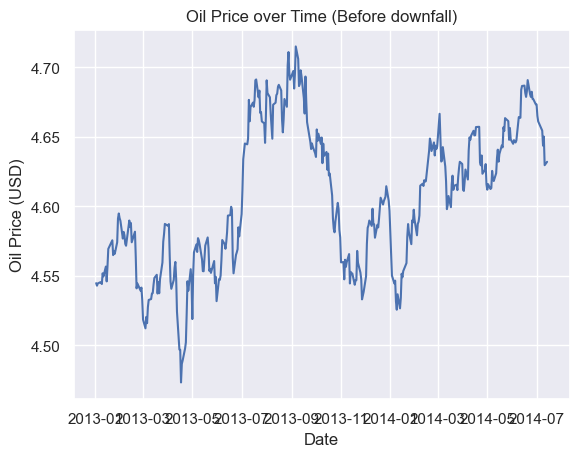

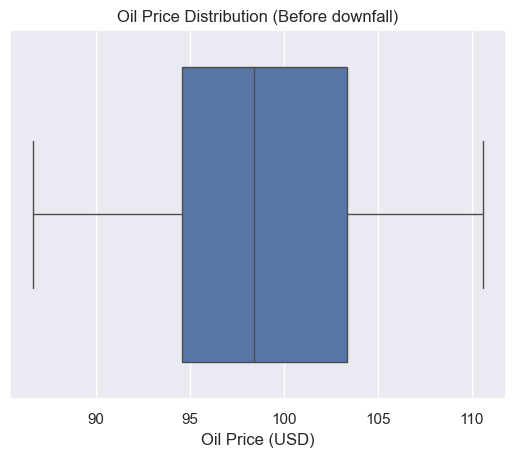

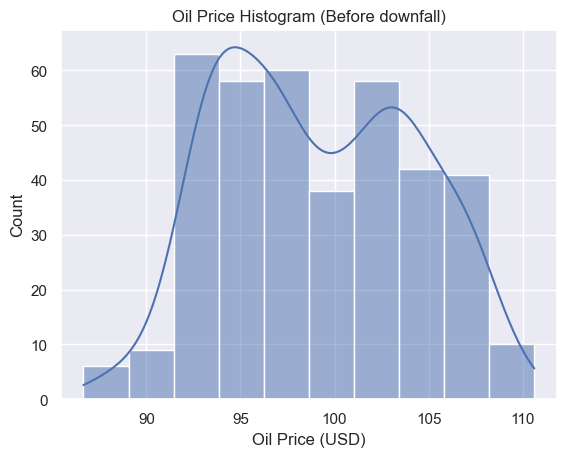

Skew (Before downfall): 0.10961283683882911
Kurtosis (Before downfall): -1.0038165037495461


In [6]:
# General info
df_oil_before_downfall = df_oil[df_oil['date'] < '2014-07-15'].copy()   

print(len(df_oil_before_downfall))
display(df_oil_before_downfall)
print(df_oil_before_downfall.info())
display(df_oil_before_downfall.describe())

# Check for null values
null_count = df_oil_before_downfall.isnull().sum()
print(null_count)

ax = sns.lineplot(
    x=df_oil_before_downfall['date'],
    y=np.log1p(df_oil_before_downfall['dcoilwtico'])
)

ax.set_title('Oil Price over Time (Before downfall)')

ax.set_xlabel('Date')
ax.set_ylabel('Oil Price (USD)')

plt.show()

ax = sns.boxplot(x=df_oil_before_downfall['dcoilwtico'])

ax.set_title('Oil Price Distribution (Before downfall)')
ax.set_xlabel('Oil Price (USD)')
plt.show()

ax = sns.histplot(df_oil_before_downfall['dcoilwtico'], kde=True)
ax.set_title('Oil Price Histogram (Before downfall)')
ax.set_xlabel('Oil Price (USD)')

plt.show()

print(f"Skew (Before downfall): {df_oil_before_downfall['dcoilwtico'].skew()}")
print(f"Kurtosis (Before downfall): {df_oil_before_downfall['dcoilwtico'].kurtosis()}")

Slightly right-skewed distribution.

### 1. 2. 2. Distribution analysis - during downfall

133


,date,dcoilwtico
400,2014-07-15,100.56
401,2014-07-16,101.88
402,2014-07-17,103.84
403,2014-07-18,103.83
404,2014-07-21,105.34
...,...,...
528,2015-01-09,48.35
529,2015-01-12,46.06
530,2015-01-13,45.92
531,2015-01-14,48.49


<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 400 to 532
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        133 non-null    datetime64[ns]
 1   dcoilwtico  129 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.1 KB
None


,date,dcoilwtico
count,133,129.000000
mean,2014-10-15 00:00:00,81.384574
min,2014-07-15 00:00:00,45.920000
25%,2014-08-29 00:00:00,68.980000
50%,2014-10-15 00:00:00,83.250000
75%,2014-12-01 00:00:00,95.390000
max,2015-01-15 00:00:00,105.680000
std,NaN,17.166989


date          0
dcoilwtico    4
dtype: int64


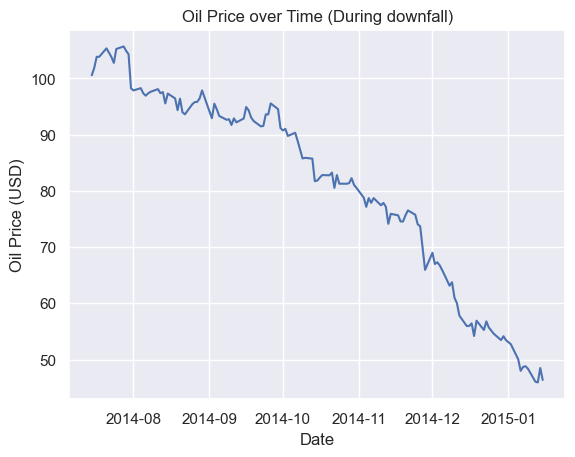

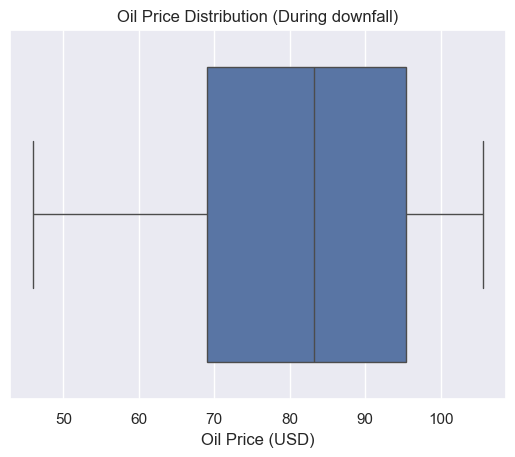

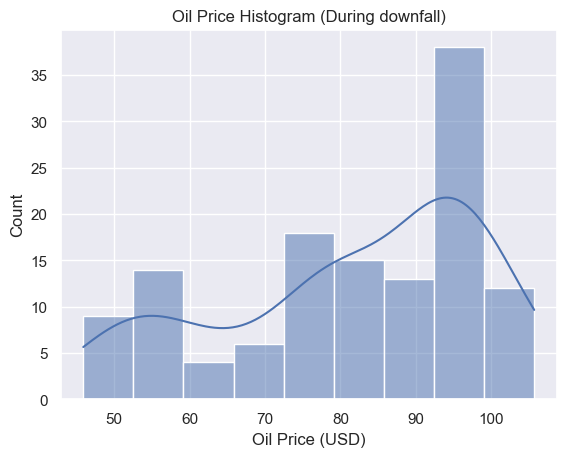

Skew (During downfall): -0.6065212020266414
Kurtosis (During downfall): -0.8198011877374611


In [7]:
df_oil_during_downfall = df_oil[
    df_oil['date'].between('2014-07-15', '2015-01-15')
].copy()

# General info
print(len(df_oil_during_downfall))
display(df_oil_during_downfall)
print(df_oil_during_downfall.info())
display(df_oil_during_downfall.describe())

# Check for null values
null_count = df_oil_during_downfall.isnull().sum()
print(null_count)

ax = sns.lineplot(
    x=df_oil_during_downfall['date'],
    y=df_oil_during_downfall['dcoilwtico']
)

ax.set_title('Oil Price over Time (During downfall)')
ax.set_xlabel('Date')
ax.set_ylabel('Oil Price (USD)')
plt.show()

ax = sns.boxplot(x=df_oil_during_downfall['dcoilwtico'])
ax.set_title('Oil Price Distribution (During downfall)')
ax.set_xlabel('Oil Price (USD)')
plt.show()

ax = sns.histplot(df_oil_during_downfall['dcoilwtico'], kde=True)
ax.set_title('Oil Price Histogram (During downfall)')
ax.set_xlabel('Oil Price (USD)')
plt.show()

print(f"Skew (During downfall): {df_oil_during_downfall['dcoilwtico'].skew()}")
print(f"Kurtosis (During downfall): {df_oil_during_downfall['dcoilwtico'].kurtosis()}")

### 1. 2. 3. Distribution analysis - after downfall

673


,date,dcoilwtico
533,2015-01-16,48.49
534,2015-01-19,NaN
535,2015-01-20,46.79
536,2015-01-21,47.85
537,2015-01-22,45.93
...,...,...
1201,2017-08-09,49.59
1202,2017-08-10,48.54
1203,2017-08-11,48.81
1204,2017-08-14,47.59


<class 'pandas.core.frame.DataFrame'>
Index: 673 entries, 533 to 1205
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        673 non-null    datetime64[ns]
 1   dcoilwtico  649 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.8 KB
None


,date,dcoilwtico
count,673,649.000000
mean,2016-05-01 04:48:51.352154624,46.753513
min,2015-01-16 00:00:00,26.190000
25%,2015-09-09 00:00:00,43.870000
50%,2016-05-02 00:00:00,47.240000
75%,2016-12-22 00:00:00,50.720000
max,2017-08-15 00:00:00,61.360000
std,NaN,6.749565


date           0
dcoilwtico    24
dtype: int64


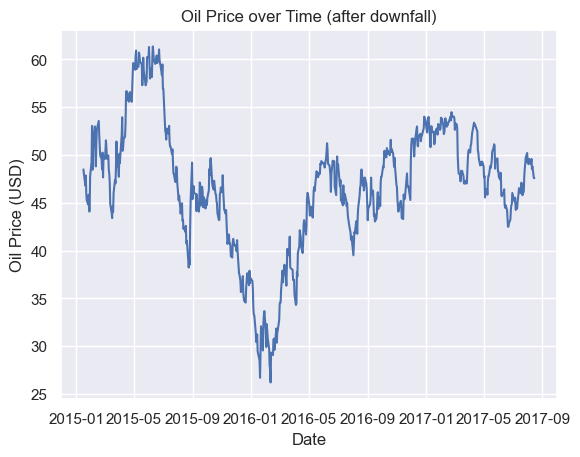

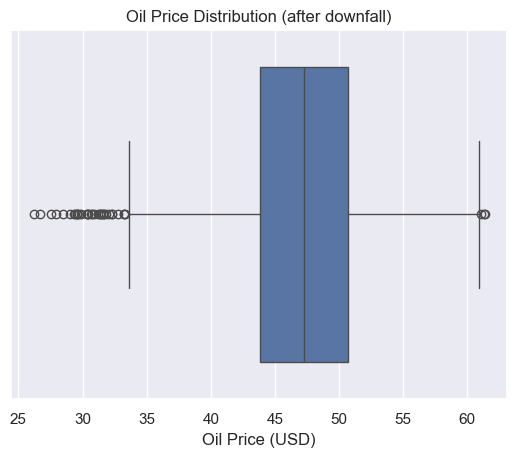

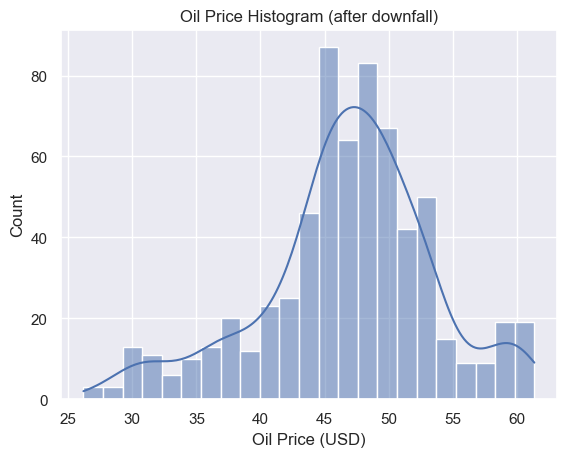

Skew (after downfall): -0.46407301940548995
Kurtosis (after downfall): 0.5163778836107413


In [8]:
# General info
df_oil_after_downfall = df_oil[df_oil['date'] > '2015-01-15'].copy()

print(len(df_oil_after_downfall))
display(df_oil_after_downfall)
print(df_oil_after_downfall.info())
display(df_oil_after_downfall.describe())

# Check for null values
null_count = df_oil_after_downfall.isnull().sum()
print(null_count)

ax = sns.lineplot(
    x=df_oil_after_downfall['date'],
    y=df_oil_after_downfall['dcoilwtico']
)

ax.set_title('Oil Price over Time (after downfall)')

ax.set_xlabel('Date')
ax.set_ylabel('Oil Price (USD)')

plt.show()

ax = sns.boxplot(x=df_oil_after_downfall['dcoilwtico'])

ax.set_title('Oil Price Distribution (after downfall)')
ax.set_xlabel('Oil Price (USD)')
plt.show()

ax = sns.histplot(df_oil_after_downfall['dcoilwtico'], kde=True)
ax.set_title('Oil Price Histogram (after downfall)')
ax.set_xlabel('Oil Price (USD)')

plt.show()

print(f"Skew (after downfall): {df_oil_after_downfall['dcoilwtico'].skew()}")
print(f"Kurtosis (after downfall): {df_oil_after_downfall['dcoilwtico'].kurtosis()}")

The oil price distribution before the downfall is right-skewed; during and after is left-skewed.

Considering this, we may or must:
- do separate correlation analysis for each one of these splits;
- use oil price variation (e. g., before yesterday's price / yesterday's price) as a feature instead of the absolute value;
- create dummy variables during the training for the periods (`is_before_downfall`, `is_during_downfall`, `is_after_downfall`).

# 2. Holiday/events

## 2. 1. Load data and check general info

In [9]:
df_holidays = pd.read_csv('../data/holidays_events.csv')

df_holidays['date'] = pd.to_datetime(df_holidays['date'])

display(df_holidays)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [10]:
print(df_holidays.info())
display(df_holidays.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB
None


,date
count,350
mean,2015-04-24 00:45:15.428571392
min,2012-03-02 00:00:00
25%,2013-12-23 06:00:00
50%,2015-06-08 00:00:00
75%,2016-07-03 00:00:00
max,2017-12-26 00:00:00


## 2. 2. Check columns' distributions

### 2. 2. 1. Type

In [11]:
# Holiday type
df_holidays['type'].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

There is a `Work Day` value. Let's check what it means.

In [12]:
display(df_holidays[df_holidays['type'] == 'Work Day'])

,date,type,locale,locale_name,description,transferred
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano,False
149,2014-12-20,Work Day,National,Ecuador,Recupero Puente Navidad,False
161,2015-01-10,Work Day,National,Ecuador,Recupero Puente Primer dia del ano,False
283,2016-11-12,Work Day,National,Ecuador,Recupero Puente Dia de Difuntos,False


Those are days that aren't actually holidays, but compensations for holidays. Therefore, they must not be considered.

Now, let's check the rows with `Transfer`.

In [13]:
display(df_holidays[df_holidays['type'] == 'Transfer'])

,date,type,locale,locale_name,description,transferred
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
73,2013-10-11,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
136,2014-10-10,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
256,2016-05-27,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False
265,2016-07-24,Transfer,Local,Guayaquil,Traslado Fundacion de Guayaquil,False
269,2016-08-12,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False
298,2017-01-02,Transfer,National,Ecuador,Traslado Primer dia del ano,False
304,2017-04-13,Transfer,Local,Cuenca,Fundacion de Cuenca,False
313,2017-05-26,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False
325,2017-08-11,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False


Those are the real holidays of transferred ones. Let's check what are them.

In [14]:
display(df_holidays[df_holidays['transferred'] == True])

,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True


As they are not real holidays, they also should not be considered.

Let's check the `Event` value.

In [15]:
display(df_holidays[df_holidays['type'] == 'Event'])

,date,type,locale,locale_name,description,transferred
55,2013-05-12,Event,National,Ecuador,Dia de la Madre,False
103,2014-05-11,Event,National,Ecuador,Dia de la Madre,False
106,2014-06-12,Event,National,Ecuador,Inauguracion Mundial de futbol Brasil,False
107,2014-06-15,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Suiza,False
108,2014-06-20,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Honduras,False
113,2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False
114,2014-06-28,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
115,2014-06-29,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
116,2014-06-30,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
117,2014-07-01,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False


Those are not actually holidays, but important events, and therefore the may taken into account differently.

In [16]:
display(df_holidays[df_holidays['type'] == 'Holiday'])

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
338,2017-11-12,Holiday,Local,Ambato,Independencia de Ambato,False
340,2017-12-06,Holiday,Local,Quito,Fundacion de Quito,True
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
344,2017-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False


Standard holidays.

In [17]:
display(df_holidays[df_holidays['type'] == 'Additional'])

,date,type,locale,locale_name,description,transferred
28,2012-12-05,Additional,Local,Quito,Fundacion de Quito-1,False
31,2012-12-21,Additional,National,Ecuador,Navidad-4,False
33,2012-12-22,Additional,National,Ecuador,Navidad-3,False
34,2012-12-23,Additional,National,Ecuador,Navidad-2,False
36,2012-12-24,Additional,National,Ecuador,Navidad-1,False
38,2012-12-26,Additional,National,Ecuador,Navidad+1,False
40,2012-12-31,Additional,National,Ecuador,Primer dia del ano-1,False
53,2013-05-11,Additional,National,Ecuador,Dia de la Madre-1,False
64,2013-07-24,Additional,Local,Guayaquil,Fundacion de Guayaquil-1,False
81,2013-12-05,Additional,Local,Quito,Fundacion de Quito-1,False


Also not actual holidays, and may be needed to taken into account differently.

In [18]:
display(df_holidays[df_holidays['type'] == 'Bridge'])

,date,type,locale,locale_name,description,transferred
35,2012-12-24,Bridge,National,Ecuador,Puente Navidad,False
39,2012-12-31,Bridge,National,Ecuador,Puente Primer dia del ano,False
156,2014-12-26,Bridge,National,Ecuador,Puente Navidad,False
160,2015-01-02,Bridge,National,Ecuador,Puente Primer dia del ano,False
277,2016-11-04,Bridge,National,Ecuador,Puente Dia de Difuntos,False


Bridge to actual holidays.

### 2. 2. 2. Locale

In [19]:
df_holidays['locale'].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [20]:
display(df_holidays[df_holidays['locale'] == 'National'])

,date,type,locale,locale_name,description,transferred
14,2012-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,False
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
21,2012-11-02,Holiday,National,Ecuador,Dia de Difuntos,False
22,2012-11-03,Holiday,National,Ecuador,Independencia de Cuenca,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


Events/holidays to whole_country.

In [21]:
display(df_holidays[df_holidays['locale'] == 'Local'])

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
...,...,...,...,...,...,...
339,2017-12-05,Additional,Local,Quito,Fundacion de Quito-1,False
340,2017-12-06,Holiday,Local,Quito,Fundacion de Quito,True
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False


Holiday/events to a given city.

In [22]:
display(df_holidays[df_holidays['locale'] == 'Regional'])

,date,type,locale,locale_name,description,transferred
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
23,2012-11-06,Holiday,Regional,Santo Domingo de los Tsachilas,Provincializacion de Santo Domingo,False
24,2012-11-07,Holiday,Regional,Santa Elena,Provincializacion Santa Elena,False
47,2013-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
58,2013-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
76,2013-11-06,Holiday,Regional,Santo Domingo de los Tsachilas,Provincializacion de Santo Domingo,False
77,2013-11-07,Holiday,Regional,Santa Elena,Provincializacion Santa Elena,False
96,2014-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
112,2014-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False


As there are events for city, regions and for the whole country, three separate joins must be done: one considering the city, other the region and other the whole country. City and region info are availale in the stores dataset.

### 2. 2. 3. Locale name

In [23]:
print(df_holidays['locale_name'].value_counts())

locale_name
Ecuador                           174
Quito                              13
Riobamba                           12
Guaranda                           12
Latacunga                          12
Ambato                             12
Guayaquil                          11
Cuenca                              7
Ibarra                              7
Salinas                             6
Loja                                6
Santa Elena                         6
Santo Domingo de los Tsachilas      6
Quevedo                             6
Manta                               6
Esmeraldas                          6
Cotopaxi                            6
El Carmen                           6
Santo Domingo                       6
Machala                             6
Imbabura                            6
Puyo                                6
Libertad                            6
Cayambe                             6
Name: count, dtype: int64


### 2. 2. 4. Description

In [24]:
print(df_holidays['description'].value_counts())

description
Carnaval                              10
Fundacion de Cuenca                    7
Fundacion de Ibarra                    7
Fundacion de Quito                     6
Provincializacion de Santo Domingo     6
                                      ..
Terremoto Manabi+8                     1
Recupero puente Navidad                1
Terremoto Manabi+10                    1
Terremoto Manabi+11                    1
Traslado Fundacion de Quito            1
Name: count, Length: 103, dtype: int64


### 2. 2. 5. Transferred

In [25]:
print(df_holidays['transferred'].value_counts())

transferred
False    338
True      12
Name: count, dtype: int64


### 2. 3. Summary
- `Work Day`'s events must not be considered as they are normal work days;
- `Event` and `Additional` events must be taken into account differently as their nature is different;
- There are national, regional and local events. The must be joined with the sales data separately. The city and region info is available at the stores dataset.

# 3. Stores

## 3. 1. Load data and check general info

In [26]:
df_stores = pd.read_csv('../data/stores.csv')

display(df_stores)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [27]:
print(df_stores.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None


In [28]:
display(df_stores.describe())

,store_nbr,cluster
count,54.000000,54.000000
mean,27.500000,8.481481
std,15.732133,4.693395
min,1.000000,1.000000
25%,14.250000,4.000000
50%,27.500000,8.500000
75%,40.750000,13.000000
max,54.000000,17.000000


## 3. 2. Check columns' distribution/unique values

### 3. 2. 1. store_nbr

In [29]:
print(df_stores['store_nbr'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54]


### 3. 2. 2. city

In [30]:
print(df_stores['city'].value_counts())

city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Manta             2
Latacunga         2
Machala           2
Ambato            2
Quevedo           1
Esmeraldas        1
Loja              1
Libertad          1
Playas            1
Daule             1
Babahoyo          1
Salinas           1
Puyo              1
Guaranda          1
Ibarra            1
Riobamba          1
Cayambe           1
El Carmen         1
Name: count, dtype: int64


### 3. 2. 3. state

In [31]:
print(df_stores['state'].value_counts())

state
Pichincha                         19
Guayas                            11
Santo Domingo de los Tsachilas     3
Azuay                              3
Manabi                             3
Cotopaxi                           2
Tungurahua                         2
Los Rios                           2
El Oro                             2
Chimborazo                         1
Imbabura                           1
Bolivar                            1
Pastaza                            1
Santa Elena                        1
Loja                               1
Esmeraldas                         1
Name: count, dtype: int64


### 3. 2. 4. type

In [32]:
print(df_stores['type'].value_counts())

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


Store metadata. No further information provided.

### 3. 2. 5. cluster

In [33]:
print(df_stores['cluster'].value_counts())

cluster
3     7
6     6
10    6
15    5
13    4
14    4
11    3
4     3
8     3
1     3
9     2
7     2
2     2
12    1
5     1
16    1
17    1
Name: count, dtype: int64


Grouping of similar stores.

# 4. Transactions

Data of the amount of all transactions by store per day. Let's analyze this to check if we can extract some useful data.

## 4. 1. Load data and check general info

In [34]:
df_transactions = pd.read_csv('../data/transactions.csv')

df_transactions['date'] = pd.to_datetime(df_transactions['date'])

# Exclude August, 2017, since it's incomplete
# and may lead to a misinterpretation of the data
df_transactions = df_transactions[df_transactions['date'] <= '2017-07-31']

display(df_transactions)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
82673,2017-07-31,50,2593
82674,2017-07-31,51,1572
82675,2017-07-31,52,2206
82676,2017-07-31,53,1065


In [35]:
print(df_transactions.info())
display(df_transactions.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 82678 entries, 0 to 82677
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          82678 non-null  datetime64[ns]
 1   store_nbr     82678 non-null  int64         
 2   transactions  82678 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.5 MB
None


,date,store_nbr,transactions
count,82678,82678.000000,82678.000000
mean,2015-05-12 17:35:46.902440960,26.933743,1695.048901
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-23 00:00:00,13.000000,1046.000000
50%,2015-05-31 00:00:00,27.000000,1393.000000
75%,2016-07-03 00:00:00,40.000000,2080.000000
max,2017-07-31 00:00:00,54.000000,8359.000000
std,NaN,15.608323,963.800966


In [36]:
# Check for null values
null_count = df_transactions.isnull().sum()
print(null_count)

date            0
store_nbr       0
transactions    0
dtype: int64


## 4. 2. Visualize values over time and distribution

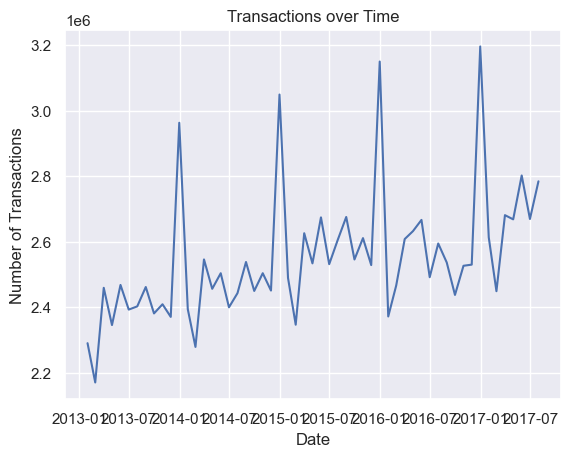

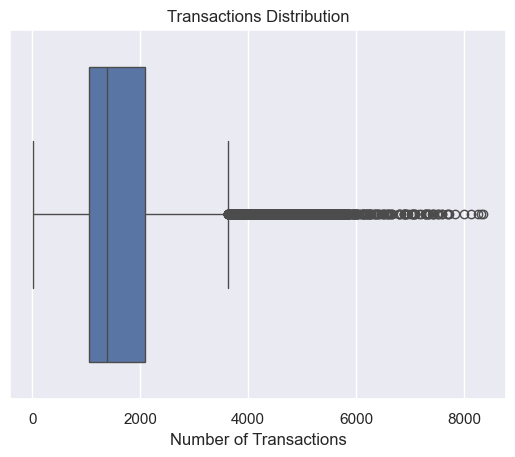

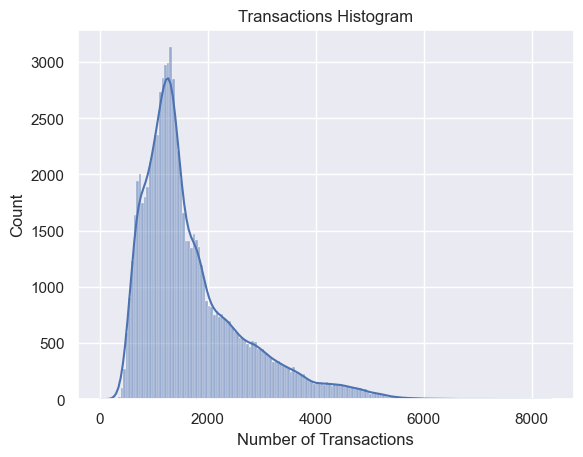

Skew: 1.519749927226462
Kurtosis: 2.575768649111826


In [37]:
# Group by month to better visualize trends/seasonality
ax = sns.lineplot(
    data=df_transactions.resample('ME', on='date').sum().reset_index().sort_values(by='date'),
    x='date',
    y='transactions'
)

ax.set_title('Transactions over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')

plt.show()

ax = sns.boxplot(
    x=df_transactions['transactions']
)

ax.set_title('Transactions Distribution')
ax.set_xlabel('Number of Transactions')
plt.show()

ax = sns.histplot(df_transactions['transactions'], kde=True)
ax.set_title('Transactions Histogram')
ax.set_xlabel('Number of Transactions')
plt.show()

print(f"Skew: {df_transactions['transactions'].skew()}")
print(f"Kurtosis: {df_transactions['transactions'].kurtosis()}")

We can see a very interesting thing: there is a clear growing trend and a very remarking seasonality pattern in the transactions. This can be used as feature (e. g., seasonality in the month/week of year of the prediction).

## 4. 2. Distribution by Granularity

In [48]:
from scipy.stats import skew, kurtosis

df_distribution_by_granularity = df_transactions.groupby(['store_nbr'])['transactions'].agg(
    skew=lambda x: skew(x),
    kurtosis=lambda x: kurtosis(x),
    total_transactions='sum',
    mean_transactions='mean'
).reset_index()

df_distribution_by_granularity

,store_nbr,skew,kurtosis,total_transactions,mean_transactions
0,1,-1.118758,0.273322,2532568,1524.724865
1,2,2.786758,23.314365,3193307,1921.364019
2,3,1.782613,6.534961,5319828,3202.786273
3,4,2.710384,15.847506,2498936,1504.476821
4,5,2.661731,15.936187,2329085,1401.374850
5,6,1.963970,8.328546,3040277,1830.389524
6,7,0.795981,5.311064,2970399,1789.396988
7,8,2.753056,17.020341,4598314,2768.400963
8,9,1.697263,7.623661,3485557,2098.468995
9,10,1.379189,5.293796,1638881,987.277711


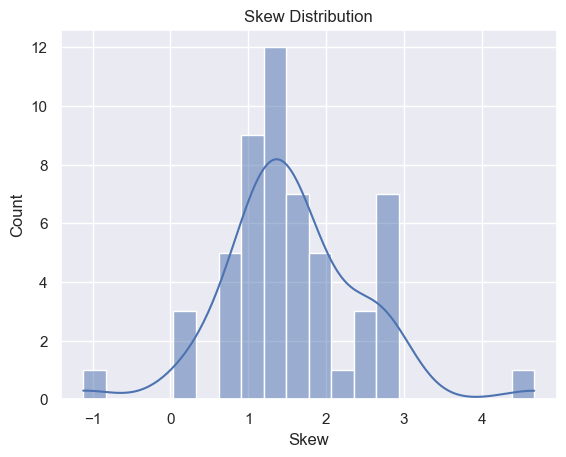

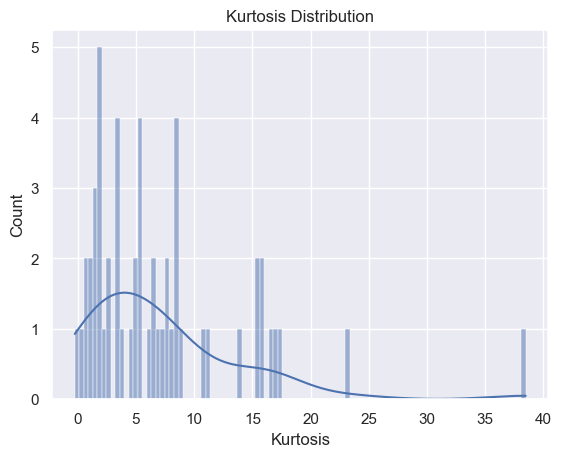

In [49]:
ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='skew',
    kde=True,
    bins=20
)

ax.set_title('Skew Distribution')
ax.set_xlabel('Skew')
ax.set_ylabel('Count')

plt.show()

ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='kurtosis',
    kde=True,
    bins=100
)

ax.set_title('Kurtosis Distribution')
ax.set_xlabel('Kurtosis')
ax.set_ylabel('Count')

plt.show()

Some higher values, specially for kurtosis, meaning that there are distributions that peak around a certain value. A log transformation or another one may be useful.

## 4. 3. Summary

There is a clear trend pattern in the data and a remarking seasonality pattern, specially in the stores with the most sales. This can be a used as a feature (i. e., week/month seasonality value). Also, there are some distributions with very high skew and specially kurtosis values. A log transformation or another one may be useful.

# 5. Conclusions
The main findings are:
- there is a clear difference in the oil price behavior during the time. It's possible to see a downfall in the data, and there is a different behavior for the variable before, during and after this. Therefore, it may be needed to use a dummy variable (`is_before_oil_price_downfall`, `is_during_oil_price_downfall`, `is_after_oil_price_downfall`) to tell the moment in time;
- it's needed to filter `Transferred` and `Work Day` events, since they are not real events/holidays;
- there is a clear seasonality pattern in the transactions data. Also, some distributions with very high skew/kurtosis values, making it needed to apply a transformation like the log one to smooth the distribution.
